Cell array with python

# Genertic Algorithm without Crossvalidation

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import trange
from sklearn.preprocessing import MinMaxScaler


# Hyperparameters
population_size = 30      # จำนวน individual
generations = 100           # จำนวน generation
feature_size = 13          # จำนวน feature
class_size = 2             # จำนวน class
crossover_prob = 0.8
mutation_prob = 0.05

In [60]:
def nomalize_data(csv):
  csv_data = np.array(csv)
  X = csv_data[:, :-1]
  y = csv_data[:, -1:]
  scaler = MinMaxScaler()
  X_scaled = scaler.fit_transform(X)
  csv_data_scaled = np.concatenate([X_scaled, y], axis=1)
  return  csv_data_scaled

In [49]:
def initial_population(population_size):

    population = np.empty(population_size , dtype='object')

    for i in range(population_size):
        population[i] =  np.random.rand(class_size,feature_size)

    return population

In [50]:
def evaluate(populations, data_train):
    X = data_train[:, :-1]
    y = data_train[:, -1:]
    performance = []

    for pop_idx, population in enumerate(populations):
        count = 0
        for i in range(len(X)):
            data_clone = np.tile(X[i], (class_size,1))
            distance = np.sqrt(np.sum((population - data_clone)**2, axis=1))
            predict = np.argmin(distance)
            if y[i] == predict:
                count += 1
        performance.append((pop_idx, count))
    return np.array(performance)

In [51]:
def roulette_wheel_selection(performance):
    total_fitness = np.sum(performance[:,1])
    probabilities = performance[:,1] / total_fitness
    ranges = []

    start = 0
    for p in probabilities:
        finish = start + p
        ranges.append((start, finish))
        start = finish
    return np.array(ranges)

In [52]:
def select_population(roulette_ranges, populations):
    num_pairs = len(roulette_ranges)//2
    parents = np.empty((num_pairs, 2), dtype='object')

    for idx in range(num_pairs):
        father_rand = np.random.uniform(0,1)
        mother_rand = np.random.uniform(0,1)

        # Father
        for i, (start, finish) in enumerate(roulette_ranges):
            if start <= father_rand and father_rand < finish:
                parents[idx, 0] = populations[i]

        # Mother
        for i, (start, finish) in enumerate(roulette_ranges):
            if start <= mother_rand and mother_rand  < finish:
                parents[idx, 1] = populations[i]

    return parents

In [53]:
# Single-point crossover

def cross_over(parents):
    num_pairs = len(parents)
    children1 = np.empty(num_pairs, dtype=object)
    children2 = np.empty(num_pairs, dtype=object)

    for index in range(num_pairs):
        father = parents[index, 0]
        mother = parents[index, 1]

        # random single-point crossover
        cross_points = np.random.permutation(np.arange(1, feature_size))
        cross_point = cross_points[0] # เอาตำแหน่งแรกเป็นจุด Crossover

        if np.random.uniform(0, 1) <= crossover_prob:
            # แบ่ง gene และสลับ
            # axis=0 → rows
            # axis=1 → column
            child1 = np.concatenate((father[:, 0:cross_point], mother[:, cross_point:]), axis=1)
            child2 = np.concatenate((mother[:, 0:cross_point], father[:, cross_point:]), axis=1)
        else:
            # ไม่มี crossover
            child1 = father
            child2 = mother

        children1[index] = child1
        children2[index] = child2

    # รวมลูกทั้งหมด
    return np.concatenate((children1, children2))




In [54]:
# def mutation(child):

#     for child_idx in range(len(child)):
#         chromosome = child[child_idx]

#         for gene_idx in range(13):
#             if np.random.random() <= mutation_prob:
#                 # ปรับค่า gene แบบสุ่ม
#                 chromosome[:, gene_idx] += (0.1 * np.random.uniform(0,1) - 0.5)

#         child[child_idx] = chromosome

#     return child

def mutation(children):
    for idx in range(len(children)):
        chromosome = children[idx]
        for gene_idx in range(feature_size):
            if np.random.random() <= mutation_prob:
                chromosome[:, gene_idx] += np.random.uniform(-0.1, 0.1)
                chromosome[:, gene_idx] = np.clip(chromosome[:, gene_idx], 0, 1)
        children[idx] = chromosome
    return children

In [55]:
def sort_after_combined(performance_combined):
    sort_idx = np.argsort(performance_combined[:,1])[::-1]
    sorted_top = performance_combined[sort_idx][:population_size]
    top_idx = sorted_top[:,0].astype(int)
    top_performance = sorted_top[:,1]
    return top_idx, top_performance

In [56]:
def genetic_flow(populations, csv_data):
    performance_record = []

    for _ in trange(generations):
        fitness = evaluate(populations, csv_data)
        roulette_ranges = roulette_wheel_selection(fitness)
        parents = select_population(roulette_ranges, populations)
        children = cross_over(parents)
        mutated_children = mutation(children)

        combined_population = np.concatenate((populations, mutated_children))
        combined_fitness = evaluate(combined_population, csv_data)

        top_idx, top_perf = sort_after_combined(combined_fitness)
        populations = combined_population[top_idx]

        performance_record.append(top_perf[0])

    model = populations[0]
    return model, performance_record

In [68]:
def evaluate_model(model , data_train):
    X = data_train[:,0:feature_size]
    y = data_train[:,-1:]

    count = 0

    for index in range(len(X)):

        data_clone = np.tile(X[index], (class_size,1))
        distance = np.sqrt(np.sum((model - data_clone)**2 ,axis=1))
        predict = np.argmin(distance)

        if predict ==  y[index]:
            count = count+1

    return count/len(X)

In [71]:
def plot_performance(performance_history, final_accuracy):
    plt.figure(figsize=(8,5))

    # Plot performance
    plt.plot(performance_history, marker='o', linestyle='-', linewidth=2, markersize=5)

    # Title & labels
    plt.title("Performance over Generations", fontsize=14, fontweight="bold")
    plt.xlabel("Generation", fontsize=12)
    plt.ylabel("Performance (Fitness/Score)", fontsize=12)

    # Grid & style
    plt.grid(True, linestyle="--", alpha=0.6)

    # แสดง Accuracy สุดท้ายเป็นข้อความ
    plt.text(len(performance_history)-1, performance_history[-1],
             f" Final Accuracy = {final_accuracy:.4f}",
             fontsize=11, color="blue", ha="right", va="bottom",
             bbox=dict(facecolor="white", alpha=0.7, edgecolor="blue"))

    plt.tight_layout()
    plt.show()

In [63]:
# main with out crossvalidation

csv_file = pd.read_csv('/content/heart.csv')
csv_data_scaled = nomalize_data(csv_file)
# Initialize population
populations = initial_population(population_size)

# Run GA
model, performance_history = genetic_flow(populations, csv_data_scaled)

100%|██████████| 100/100 [02:53<00:00,  1.74s/it]


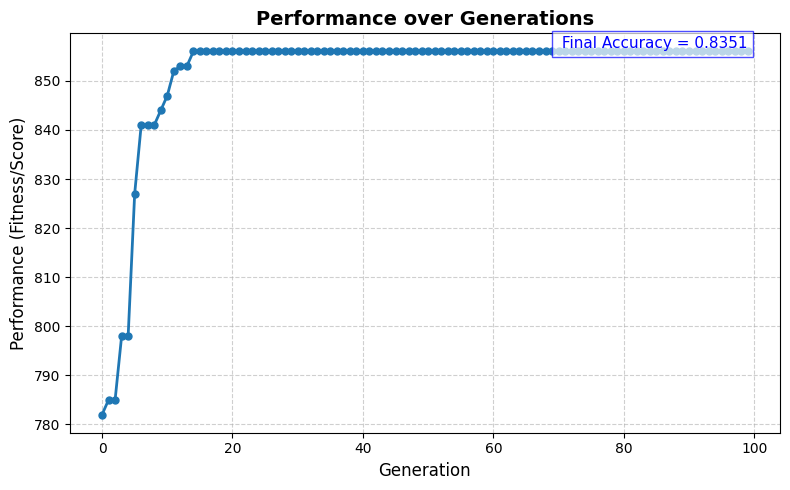

In [73]:
accuracy = evaluate_model(model,csv_data_scaled)
plot_performance(performance_history,accuracy )